# Logistic Regression

**Flow:** linear score → sigmoid probability → held-out split → threshold → confusion matrix → ROC.

Logistic regression models a **probability**. A threshold converts it to a class label; 0.5 is conventional, not mandatory. We evaluate on held-out test data only.

## 1. Setup and versions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score,
                             roc_curve, roc_auc_score)

rng = np.random.default_rng(42)

OKABE_ITO = [
    '#0072B2',  # blue
    '#E69F00',  # orange
    '#009E73',  # bluish green
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
    '#56B4E9',  # sky blue
    '#F0E442',  # yellow
    '#000000',  # black
]


In [2]:
# Environment / version info for reproducibility
import sys
import numpy as np
import scipy
import sklearn
import matplotlib

print('Python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('scipy       :', scipy.__version__)
print('scikit-learn:', sklearn.__version__)
print('matplotlib  :', matplotlib.__version__)


Python      : 3.9.25
numpy       : 1.26.4
scipy       : 1.13.1
scikit-learn: 1.4.2
matplotlib  : 3.8.4


## 2. The sigmoid maps a score to a probability
The linear score can be any real number; the sigmoid squashes it into (0, 1).

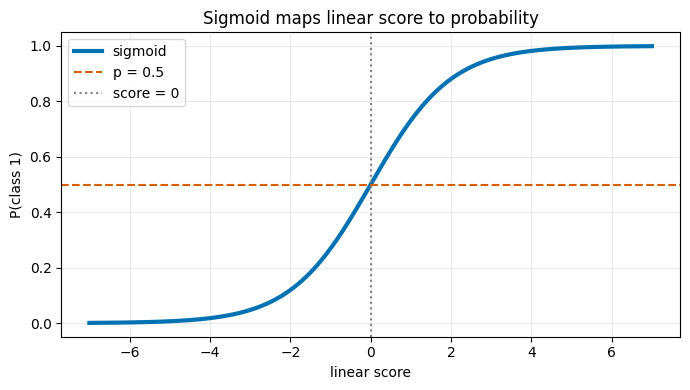

In [3]:
z = np.linspace(-7, 7, 300)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(7, 4))
plt.plot(z, sigmoid, color=OKABE_ITO[0], lw=3, label='sigmoid')
plt.axhline(0.5, color=OKABE_ITO[3], ls='--', label='p = 0.5')
plt.axvline(0, color='0.5', ls=':', label='score = 0')
plt.title('Sigmoid maps linear score to probability')
plt.xlabel('linear score'); plt.ylabel('P(class 1)')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()


## 3. Data and held-out split
We generate a 2-feature binary problem and split into train/test **before** fitting. scikit-learn `LogisticRegression` applies L2 regularization by default.

In [4]:
X = rng.normal(size=(300, 2))
logits = X[:, 0] + 0.8 * X[:, 1] + rng.normal(0, 0.7, size=300)
y = (logits > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=4, stratify=y
)
clf = Pipeline([
    ('scale', StandardScaler()),
    ('logit', LogisticRegression()),
]).fit(X_train, y_train)
print(f'Train/test sizes: {X_train.shape[0]} / {X_test.shape[0]}')
print(f'Test class balance: {np.bincount(y_test)}')


Train/test sizes: 210 / 90
Test class balance: [47 43]


## 4. Predicted probabilities on the test set
Points are colored by predicted probability using the perceptually uniform, colorblind-safe **viridis** colormap, with a **colorbar** for the continuous value.

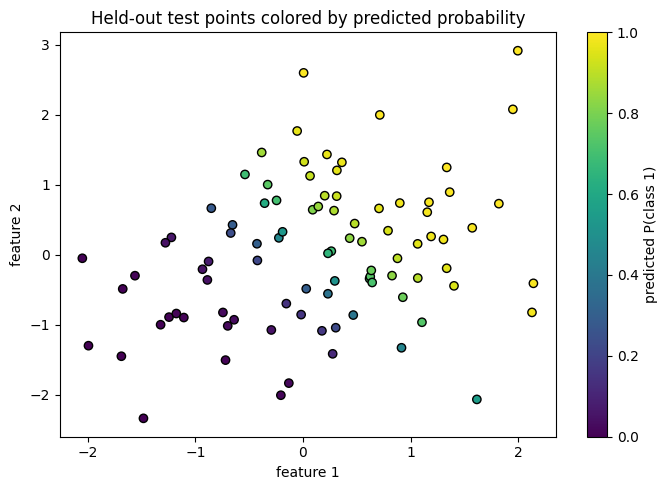

In [5]:
test_prob = clf.predict_proba(X_test)[:, 1]

plt.figure(figsize=(7, 5))
sc = plt.scatter(X_test[:, 0], X_test[:, 1], c=test_prob,
                 cmap='viridis', edgecolor='black', vmin=0, vmax=1)
cbar = plt.colorbar(sc)
cbar.set_label('predicted P(class 1)')
plt.title('Held-out test points colored by predicted probability')
plt.xlabel('feature 1'); plt.ylabel('feature 2')
plt.tight_layout(); plt.show()


## 5. Threshold and confusion matrix (test data)
A threshold turns probabilities into labels. The confusion matrix is annotated with counts, class labels, and a colorbar.

Threshold      : 0.5
Accuracy       : 0.822
Precision      : 0.755
Recall         : 0.930


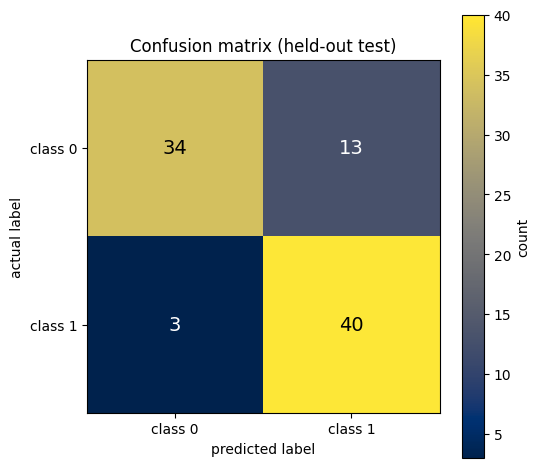

In [6]:
threshold = 0.5
test_pred = (test_prob >= threshold).astype(int)
cm = confusion_matrix(y_test, test_pred)

print(f'Threshold      : {threshold}')
print(f'Accuracy       : {accuracy_score(y_test, test_pred):.3f}')
print(f'Precision      : {precision_score(y_test, test_pred):.3f}')
print(f'Recall         : {recall_score(y_test, test_pred):.3f}')

labels = ['class 0', 'class 1']
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap='cividis')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('count')
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel('predicted label'); ax.set_ylabel('actual label')
ax.set_title('Confusion matrix (held-out test)')
thresh_col = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] < thresh_col else 'black',
                fontsize=14)
plt.tight_layout(); plt.show()


## 6. ROC curve and threshold sweep (test data)
The ROC curve shows the trade-off between true-positive and false-positive rates as the threshold varies. AUC summarizes it. We also mark the default 0.5 threshold operating point.

ROC AUC (test): 0.913
At threshold ~0.5 -> FPR=0.319, TPR=0.930


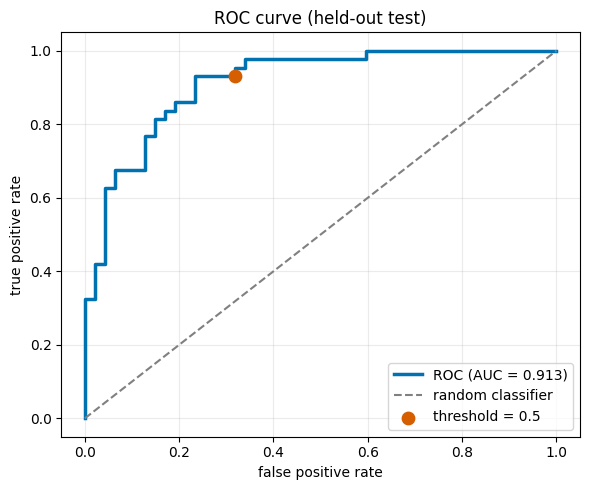

In [7]:
fpr, tpr, thr = roc_curve(y_test, test_prob)
auc = roc_auc_score(y_test, test_prob)

# Operating point closest to threshold 0.5
idx = np.argmin(np.abs(thr - 0.5))
print(f'ROC AUC (test): {auc:.3f}')
print(f'At threshold ~0.5 -> FPR={fpr[idx]:.3f}, TPR={tpr[idx]:.3f}')

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color=OKABE_ITO[0], lw=2.5,
         label=f'ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='0.5', ls='--', label='random classifier')
plt.scatter([fpr[idx]], [tpr[idx]], color=OKABE_ITO[3], marker='o',
            s=80, zorder=5, label='threshold = 0.5')
plt.title('ROC curve (held-out test)')
plt.xlabel('false positive rate'); plt.ylabel('true positive rate')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()


## Takeaways
- Fit on training data; evaluate probabilities and labels on the held-out test set.
- The threshold is a decision, not a fixed property of the model.
- Confusion matrix and ROC/AUC describe complementary aspects of classification quality.